# Chapter 173 — Singular Value Decomposition (SVD)

> **Prerequisites:** ch172 (Diagonalization), ch155 (Matrix Transpose), ch166 (Rotations via Matrices), ch168 (Projection Matrices)
> **You will learn:**
> - What SVD is and why it works for *any* matrix (not just square/symmetric)
> - The geometric meaning of U, Σ, Vᵀ
> - How truncated SVD enables compression and denoising
> - Why SVD is the most important matrix decomposition in data science
> **Environment:** Python 3.x, numpy, matplotlib

## 1. Concept

Eigendecomposition A = VΛV⁻¹ requires A to be square and diagonalizable. SVD removes both constraints.

Every matrix M (m×n) — rectangular or square, any rank — can be factored as:

    M = U Σ Vᵀ

Where:
- **U**: m×m orthogonal matrix (left singular vectors — column space basis)
- **Σ**: m×n diagonal matrix of non-negative singular values σ₁ ≥ σ₂ ≥ ... ≥ 0
- **Vᵀ**: n×n orthogonal matrix (right singular vectors — row space basis)

SVD says: every linear map is a rotation/reflection (Vᵀ), followed by axis-aligned scaling (Σ), followed by another rotation/reflection (U).

**Singular values** σᵢ = √λᵢ where λᵢ are eigenvalues of MᵀM (or MMᵀ for the left side).

## 2. Intuition & Mental Models

**Geometric:** Every matrix M transforms the unit sphere in ℝⁿ into an ellipsoid in ℝᵐ. The singular values are the axis lengths of that ellipsoid. The right singular vectors (columns of V) are the input directions that become the ellipsoid axes. The left singular vectors (columns of U) are those axes in output space.

**Rank-1 decomposition:** SVD expresses M as a sum of rank-1 matrices:

    M = σ₁·u₁v₁ᵀ + σ₂·u₂v₂ᵀ + ... + σᵣ·uᵣvᵣᵀ

The first term captures the most important structure (largest σ₁), the second adds refinement, and so on. **Truncated SVD** keeps only the first k terms — this is the mathematical foundation of image compression, topic modeling, and collaborative filtering.

**Connection to eigendecomposition:** Mᵀ M = V Σᵀ Uᵀ U Σ Vᵀ = V (ΣᵀΣ) Vᵀ. So V diagonalizes Mᵀ M, and σᵢ = √λᵢ(MᵀM).

Recall from ch172 that diagonalization requires square diagonalizable matrices. SVD sidesteps this by working with MᵀM (always symmetric positive semidefinite) and MMᵀ (same).

## 3. Visualization

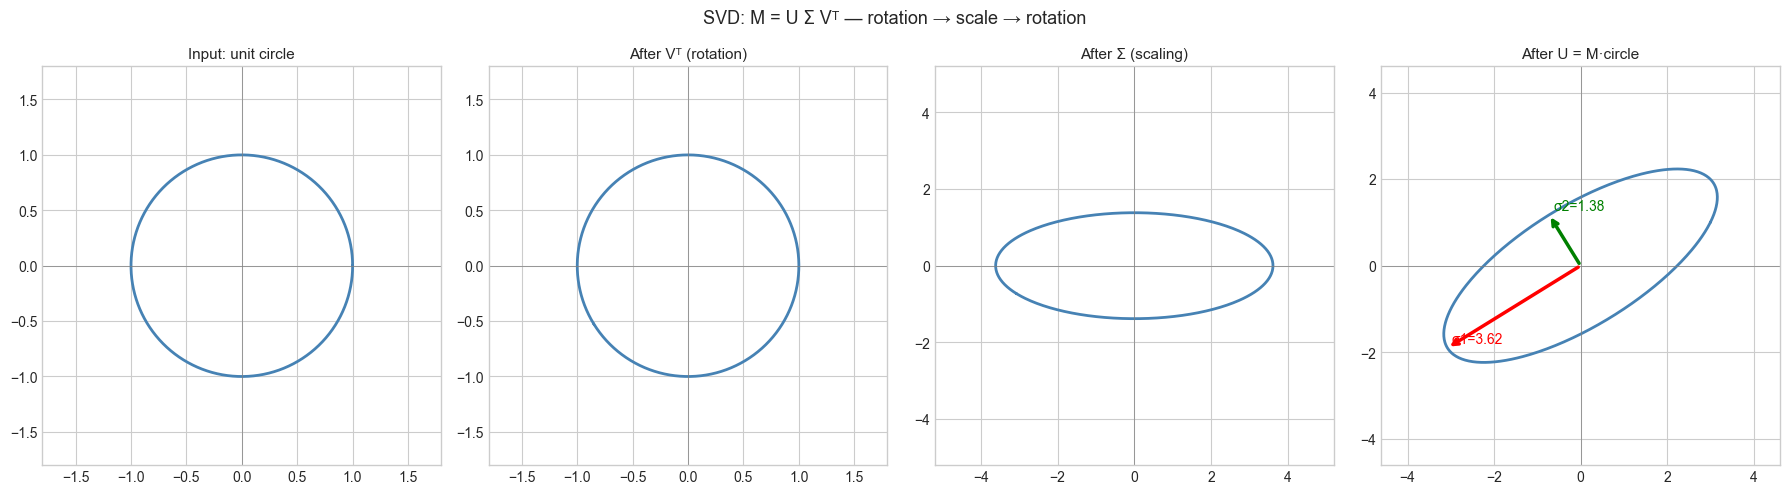

Singular values: [3.61803399 1.38196601]
Rank of M: 2


In [1]:
# --- Visualization: SVD transforms unit circle to ellipse via three steps ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

M = np.array([[3.0, 1.0],
              [1.0, 2.0]])

U, s, Vt = np.linalg.svd(M)
Sigma = np.diag(s)

# Unit circle
theta = np.linspace(0, 2*np.pi, 400)
circle = np.stack([np.cos(theta), np.sin(theta)])  # (2, 400)

# Three intermediate stages
stage1 = Vt @ circle          # Vᵀ: first rotation
stage2 = Sigma @ stage1       # Σ: scaling
stage3 = U @ stage2           # U: second rotation = M·circle

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
stages = [circle, stage1, stage2, stage3]
titles = ['Input: unit circle', 'After Vᵀ (rotation)', 'After Σ (scaling)', 'After U = M·circle']

for ax, data, title in zip(axes, stages, titles):
    ax.plot(data[0], data[1], 'steelblue', lw=2)
    lim = max(abs(data.max()), abs(data.min())) * 1.3 + 0.5
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    ax.set_aspect('equal')
    ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
    ax.set_title(title, fontsize=11)

# Add singular vectors to final plot
for i in range(2):
    axes[3].annotate('', xy=U[:, i]*s[i], xytext=(0, 0),
                     arrowprops=dict(arrowstyle='->', color=['red','green'][i], lw=2.5))
    axes[3].text(U[0,i]*s[i]+.1, U[1,i]*s[i]+.1,
                 f'σ{i+1}={s[i]:.2f}', color=['red','green'][i], fontsize=10)

plt.suptitle('SVD: M = U Σ Vᵀ — rotation → scale → rotation', fontsize=13)
plt.tight_layout()
plt.show()
print(f"Singular values: {s}")
print(f"Rank of M: {np.linalg.matrix_rank(M)}")

## 4. Mathematical Formulation

**Existence:** Every m×n matrix M has an SVD M = UΣVᵀ.

- U is m×m orthogonal (UᵀU = I)
- V is n×n orthogonal (VᵀV = I)
- Σ is m×n with σ₁ ≥ σ₂ ≥ ... ≥ σᵣ > 0 on diagonal, zeros elsewhere
- r = rank(M)

**Truncated SVD (best rank-k approximation):**

    Mₖ = Σᵢ₌₁ᵏ σᵢ uᵢ vᵢᵀ

The Eckart-Young theorem: Mₖ is the best rank-k approximation to M in both Frobenius and spectral norms.

    ||M - Mₖ||_F² = σ_{k+1}² + ... + σᵣ²

**Relationship to eigendecomposition:**

    MᵀM = V Σᵀ Σ Vᵀ   →  eigenvalues of MᵀM are σᵢ²
    MMᵀ = U Σ Σᵀ Uᵀ   →  eigenvalues of MMᵀ are σᵢ²

## 5. Python Implementation

In [2]:
# --- Implementation: SVD from scratch via eigendecomposition of M^T M ---
import numpy as np

def svd_via_eig(M):
    """
    Compute SVD of matrix M using eigendecomposition of M^T M.

    Args:
        M: (m, n) numpy array

    Returns:
        U: (m, m) left singular vectors
        s: (min(m,n),) singular values in decreasing order
        Vt: (n, n) right singular vectors transposed
    """
    # Step 1: Eigendecompose M^T M
    MtM = M.T @ M
    eigvals, V = np.linalg.eigh(MtM)  # eigh: symmetric, real eigenvalues

    # Sort in decreasing order
    idx = np.argsort(eigvals)[::-1]
    eigvals = eigvals[idx]
    V = V[:, idx]

    # Step 2: Singular values = sqrt(eigenvalues), clip numerical negatives
    s = np.sqrt(np.maximum(eigvals, 0))

    # Step 3: Left singular vectors U = M V / sigma
    m = M.shape[0]
    U = np.zeros((m, m))
    r = np.sum(s > 1e-10)  # numerical rank
    for i in range(r):
        U[:, i] = M @ V[:, i] / s[i]

    # Complete U with orthonormal basis for null space if needed
    if r < m:
        # Gram-Schmidt to complete the basis
        for i in range(r, m):
            v = np.random.randn(m)
            for j in range(i):
                v -= (v @ U[:, j]) * U[:, j]
            U[:, i] = v / np.linalg.norm(v)

    return U, s[:min(m, M.shape[1])], V.T


# Test
M = np.array([[3.0, 2.0, 1.0],
              [1.0, 3.0, 2.0],
              [2.0, 1.0, 4.0]])

U_ours, s_ours, Vt_ours = svd_via_eig(M)
U_np, s_np, Vt_np = np.linalg.svd(M)

print("Our singular values: ", s_ours)
print("NumPy singular values:", s_np)
print(f"Max difference: {np.max(np.abs(s_ours - s_np)):.2e}")

# Reconstruction
M_rec = U_ours @ np.diag(np.pad(s_ours, (0, M.shape[0]-len(s_ours)))) @ Vt_ours
print(f"Reconstruction error: {np.max(np.abs(M - M_rec)):.2e}")

Our singular values:  [6.38719961 2.30838907 1.69558869]
NumPy singular values: [6.38719961 2.30838907 1.69558869]
Max difference: 2.22e-15
Reconstruction error: 1.78e-15


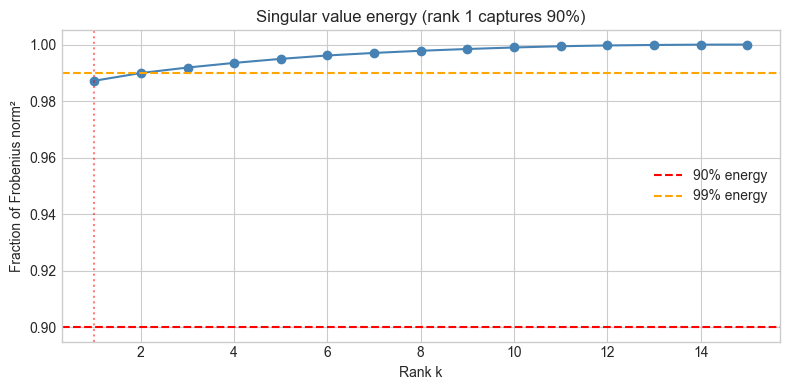

Singular values: [143.2    7.55   6.34   5.85   5.44   5.     4.32   3.99] ...


In [3]:
# --- Truncated SVD: best low-rank approximation ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

def truncated_svd(M, k):
    """
    Best rank-k approximation to M via truncated SVD.

    Returns:
        M_k: (m, n) rank-k approximation
        fraction_explained: fraction of Frobenius norm captured
    """
    U, s, Vt = np.linalg.svd(M, full_matrices=False)
    M_k = U[:, :k] @ np.diag(s[:k]) @ Vt[:k, :]
    frac = np.sum(s[:k]**2) / np.sum(s**2)
    return M_k, frac

# Random matrix to demonstrate energy captured
np.random.seed(0)
M = np.random.randn(20, 15) + np.outer(np.ones(20), np.arange(15))  # low-rank signal + noise
_, s, _ = np.linalg.svd(M)

ranks = list(range(1, min(M.shape)+1))
energy = [np.sum(s[:k]**2)/np.sum(s**2) for k in ranks]

plt.figure(figsize=(8, 4))
plt.plot(ranks, energy, 'o-', color='steelblue')
plt.axhline(0.9, color='red', ls='--', label='90% energy')
plt.axhline(0.99, color='orange', ls='--', label='99% energy')
k90 = next(k for k, e in zip(ranks, energy) if e >= 0.9)
plt.axvline(k90, color='red', ls=':', alpha=0.5)
plt.xlabel('Rank k')
plt.ylabel('Fraction of Frobenius norm²')
plt.title(f'Singular value energy (rank {k90} captures 90%)')
plt.legend()
plt.tight_layout()
plt.show()
print(f"Singular values: {s[:8].round(2)} ...")

## 6. Experiments

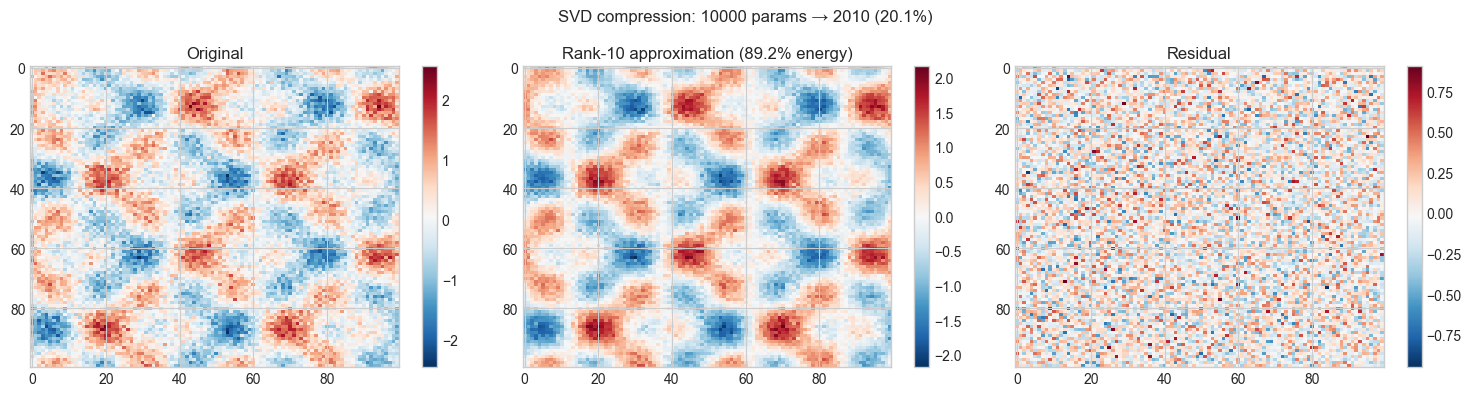

In [4]:
# --- Experiment 1: SVD compression of a synthetic image ---
# Hypothesis: A rank-k truncated SVD captures the main structures at much smaller storage
# Try changing: K_RANK

import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

K_RANK = 10  # try: 1, 5, 10, 30, 50

# Synthetic "image": smooth structure + noise
np.random.seed(1)
x = np.linspace(0, 4*np.pi, 100)
signal = np.outer(np.sin(x), np.cos(x)) + np.outer(np.cos(2*x), np.sin(2*x))
img = signal + 0.3 * np.random.randn(*signal.shape)

U, s, Vt = np.linalg.svd(img, full_matrices=False)
img_k = U[:, :K_RANK] @ np.diag(s[:K_RANK]) @ Vt[:K_RANK, :]

frac_energy = np.sum(s[:K_RANK]**2) / np.sum(s**2)
original_params = img.shape[0] * img.shape[1]
compressed_params = K_RANK * (img.shape[0] + img.shape[1] + 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, data, title in zip(axes,
                            [img, img_k, img - img_k],
                            ['Original', f'Rank-{K_RANK} approximation ({frac_energy:.1%} energy)', 'Residual']):
    im = ax.imshow(data, cmap='RdBu_r', aspect='auto')
    ax.set_title(title)
    plt.colorbar(im, ax=ax)

plt.suptitle(f'SVD compression: {original_params} params → {compressed_params} ({compressed_params/original_params:.1%})',
             fontsize=12)
plt.tight_layout()
plt.show()

In [5]:
# --- Experiment 2: Pseudoinverse via SVD ---
# Hypothesis: The Moore-Penrose pseudoinverse solves Ax=b in a least-squares sense
#             even when A is non-square or singular
# Try changing: make A fat (more columns than rows) or singular

import numpy as np

# Overdetermined system (more equations than unknowns)
np.random.seed(42)
A = np.random.randn(10, 4)  # 10 equations, 4 unknowns
x_true = np.array([1.0, 2.0, -1.0, 0.5])
b = A @ x_true + 0.1 * np.random.randn(10)  # noisy observations

# SVD-based pseudoinverse: A⁺ = V Σ⁺ Uᵀ
U, s, Vt = np.linalg.svd(A, full_matrices=False)
TOL = 1e-10
s_inv = np.where(s > TOL, 1.0/s, 0.0)  # invert nonzero singular values
A_pinv = Vt.T @ np.diag(s_inv) @ U.T

x_svd = A_pinv @ b
x_lstsq = np.linalg.lstsq(A, b, rcond=None)[0]

print(f"True x:       {x_true}")
print(f"SVD solution: {x_svd.round(4)}")
print(f"lstsq:        {x_lstsq.round(4)}")
print(f"Residual (SVD): {np.linalg.norm(A @ x_svd - b):.6f}")

True x:       [ 1.   2.  -1.   0.5]
SVD solution: [ 1.0042  2.0126 -0.965   0.5395]
lstsq:        [ 1.0042  2.0126 -0.965   0.5395]
Residual (SVD): 0.189131


## 7. Exercises

**Easy 1.** What are the singular values of an orthogonal matrix Q? Prove it analytically, then verify for a rotation matrix.

**Easy 2.** The nuclear norm of M is the sum of its singular values: ||M||_* = Σ σᵢ. Compute this for three matrices and verify it satisfies ||M||_* ≥ ||M||_F / √r where r is the rank.

**Medium 1.** Implement `truncated_svd` and use it to compress the NumPy array representation of a grayscale image. Plot the reconstruction error as a function of rank k on a log scale. At what rank does the error plateau (approaching the noise floor)?

**Medium 2.** The condition number of a matrix is σ_max / σ_min *(from ch163 — LU Decomposition)*. Build a 5×5 matrix with a prescribed condition number (construct M = U Σ Vᵀ directly with chosen σ values) and observe how the condition number affects the accuracy of linear system solutions.

**Hard.** Prove the Eckart-Young theorem for the Frobenius norm: the rank-k truncated SVD Mₖ minimizes ||M - B||_F over all rank-k matrices B. (Hint: use the orthogonality of U and V and the structure of Σ.)

## 8. Mini Project: LSA — Latent Semantic Analysis

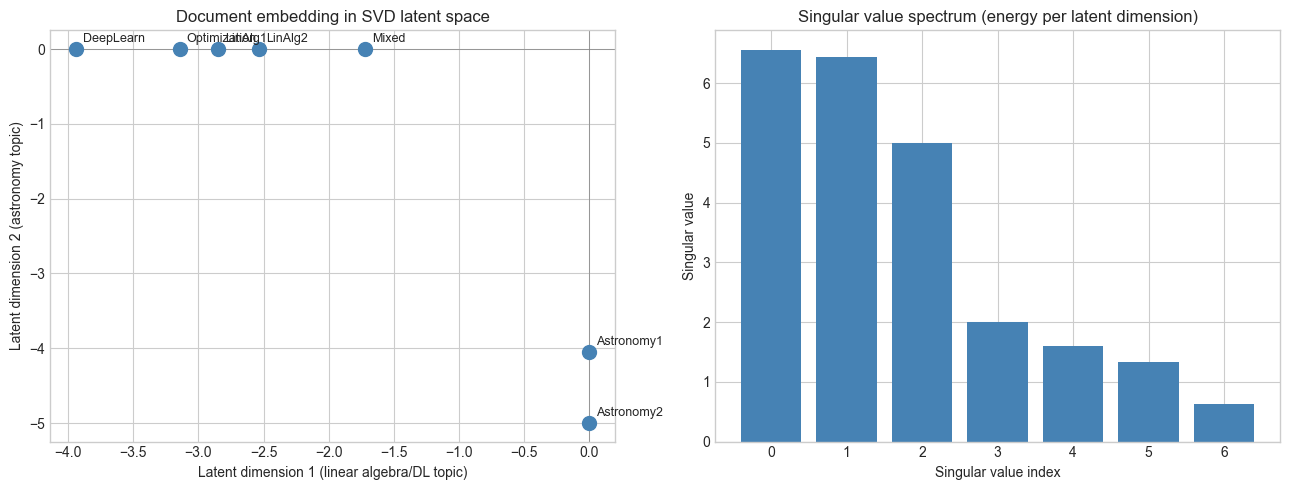


Most similar documents to 'Mixed':
  LinAlg1        : cosine similarity = 1.0000
  LinAlg2        : cosine similarity = 1.0000
  DeepLearn      : cosine similarity = 1.0000
  Optimization   : cosine similarity = 1.0000
  Astronomy1     : cosine similarity = -0.0000
  Astronomy2     : cosine similarity = -0.0000


In [6]:
# --- Mini Project: Document similarity via truncated SVD ---
# Problem: Given a term-document matrix, use SVD to find latent topics
#          and measure document similarity in the reduced space.
# Dataset: Manually constructed 7-document, 10-term example.

import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

# Terms (rows) x Documents (columns)
terms = ['matrix', 'vector', 'eigenvalue', 'neural', 'network', 'gradient',
         'star', 'galaxy', 'telescope', 'planet']
docs = ['LinAlg1', 'LinAlg2', 'DeepLearn', 'Optimization', 'Astronomy1', 'Astronomy2', 'Mixed']

# Term-document matrix (counts)
TD = np.array([
    # LA1  LA2  DL   Opt  Ast1 Ast2 Mix
    [3,    2,   1,   0,   0,   0,   1],  # matrix
    [2,    3,   0,   1,   0,   0,   1],  # vector
    [1,    2,   0,   0,   0,   0,   0],  # eigenvalue
    [0,    0,   3,   2,   0,   0,   1],  # neural
    [0,    0,   3,   1,   0,   0,   1],  # network
    [1,    0,   2,   3,   0,   0,   0],  # gradient
    [0,    0,   0,   0,   3,   2,   0],  # star
    [0,    0,   0,   0,   2,   3,   0],  # galaxy
    [0,    0,   0,   0,   2,   2,   0],  # telescope
    [0,    0,   0,   0,   1,   3,   0],  # planet
], dtype=float)

# Truncated SVD with k=2 topics
K = 2
U, s, Vt = np.linalg.svd(TD, full_matrices=False)
# Document coordinates in latent space
doc_coords = np.diag(s[:K]) @ Vt[:K, :]  # (K, n_docs)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Plot documents in 2D latent space
ax = axes[0]
ax.scatter(doc_coords[0], doc_coords[1], s=100, color='steelblue', zorder=3)
for i, doc in enumerate(docs):
    ax.annotate(doc, (doc_coords[0, i], doc_coords[1, i]),
                textcoords='offset points', xytext=(5, 5), fontsize=9)
ax.set_xlabel('Latent dimension 1 (linear algebra/DL topic)')
ax.set_ylabel('Latent dimension 2 (astronomy topic)')
ax.set_title('Document embedding in SVD latent space')
ax.axhline(0, color='gray', lw=0.5)
ax.axvline(0, color='gray', lw=0.5)

# Singular value spectrum
axes[1].bar(range(len(s)), s, color='steelblue')
axes[1].set_xlabel('Singular value index')
axes[1].set_ylabel('Singular value')
axes[1].set_title('Singular value spectrum (energy per latent dimension)')

plt.tight_layout()
plt.show()

# Compute cosine similarity between Mixed doc and all others
mixed = doc_coords[:, 6]
sims = []
for i, doc in enumerate(docs[:-1]):
    d = doc_coords[:, i]
    cos_sim = (mixed @ d) / (np.linalg.norm(mixed) * np.linalg.norm(d))
    sims.append((doc, cos_sim))
sims.sort(key=lambda x: -x[1])
print("\nMost similar documents to 'Mixed':")
for doc, sim in sims:
    print(f"  {doc:15s}: cosine similarity = {sim:.4f}")

## 9. Chapter Summary & Connections

- SVD M = UΣVᵀ works for any matrix: rectangular, singular, or rank-deficient.
- Geometric interpretation: every linear map = rotation × axis-aligned scaling × rotation.
- Truncated SVD (rank-k) is the best low-rank approximation (Eckart-Young theorem).
- Singular values = √(eigenvalues of MᵀM); they measure how much each direction is stretched.
- The pseudoinverse via SVD solves least-squares problems with full numerical stability.

**Backward:** Generalizes ch172 (Diagonalization) to non-square matrices. Uses ch168 (Projection) — the pseudoinverse projects b onto the column space of A.

**Forward:**
- ch174 (PCA Intuition): PCA is SVD of the centered data matrix
- ch180 (Project: Image Compression with SVD): direct application of truncated SVD
- ch183 (Recommender System Basics): SVD factorizes the user-item rating matrix
- ch189 (Latent Factor Model): SVD as a latent factor model for collaborative filtering

**Going deeper:** Randomized SVD (Halko et al. 2011) computes approximate truncated SVD in O(mn log k) time instead of O(mn·min(m,n)) — essential for large-scale data.